# Model 6 - Start service after some time with no arrival; individual arrivals (detailed diagrams)

## Load libraries

In [1]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

import libs.tools as tools

plt.style.use('seaborn-v0_8')

## Load and process data

In [2]:
# Number of operators needed in bS=1 case
c_needed = 16

data = tools.prepare_statistics(c_needed, lambda rec: rec["mode"] == "time-last" and rec["b_min"] == 16 and isinstance(rec["bI"], int))
base_data = tools.prepare_statistics(c_needed, lambda rec: rec["mode"] == "fixed" and rec["b_min"] == 16 and isinstance(rec["bI"], int))
tools.load_statistics(data)
tools.load_statistics(base_data)

### Calculate E[W] increasement relative to no early release case

In [3]:
for rec in data:
    save_mode = rec["mode"]
    rec["mode"] = "fixed"
    base = tools.find_same_with_other_b(base_data, rec, 1, c_needed, c_needed, None)
    rec["mode"] = save_mode
    rec["E[W]rel"] = rec["E[W]"] / base["E[W]"]

## Plot results

### Plot E[W] (relative)

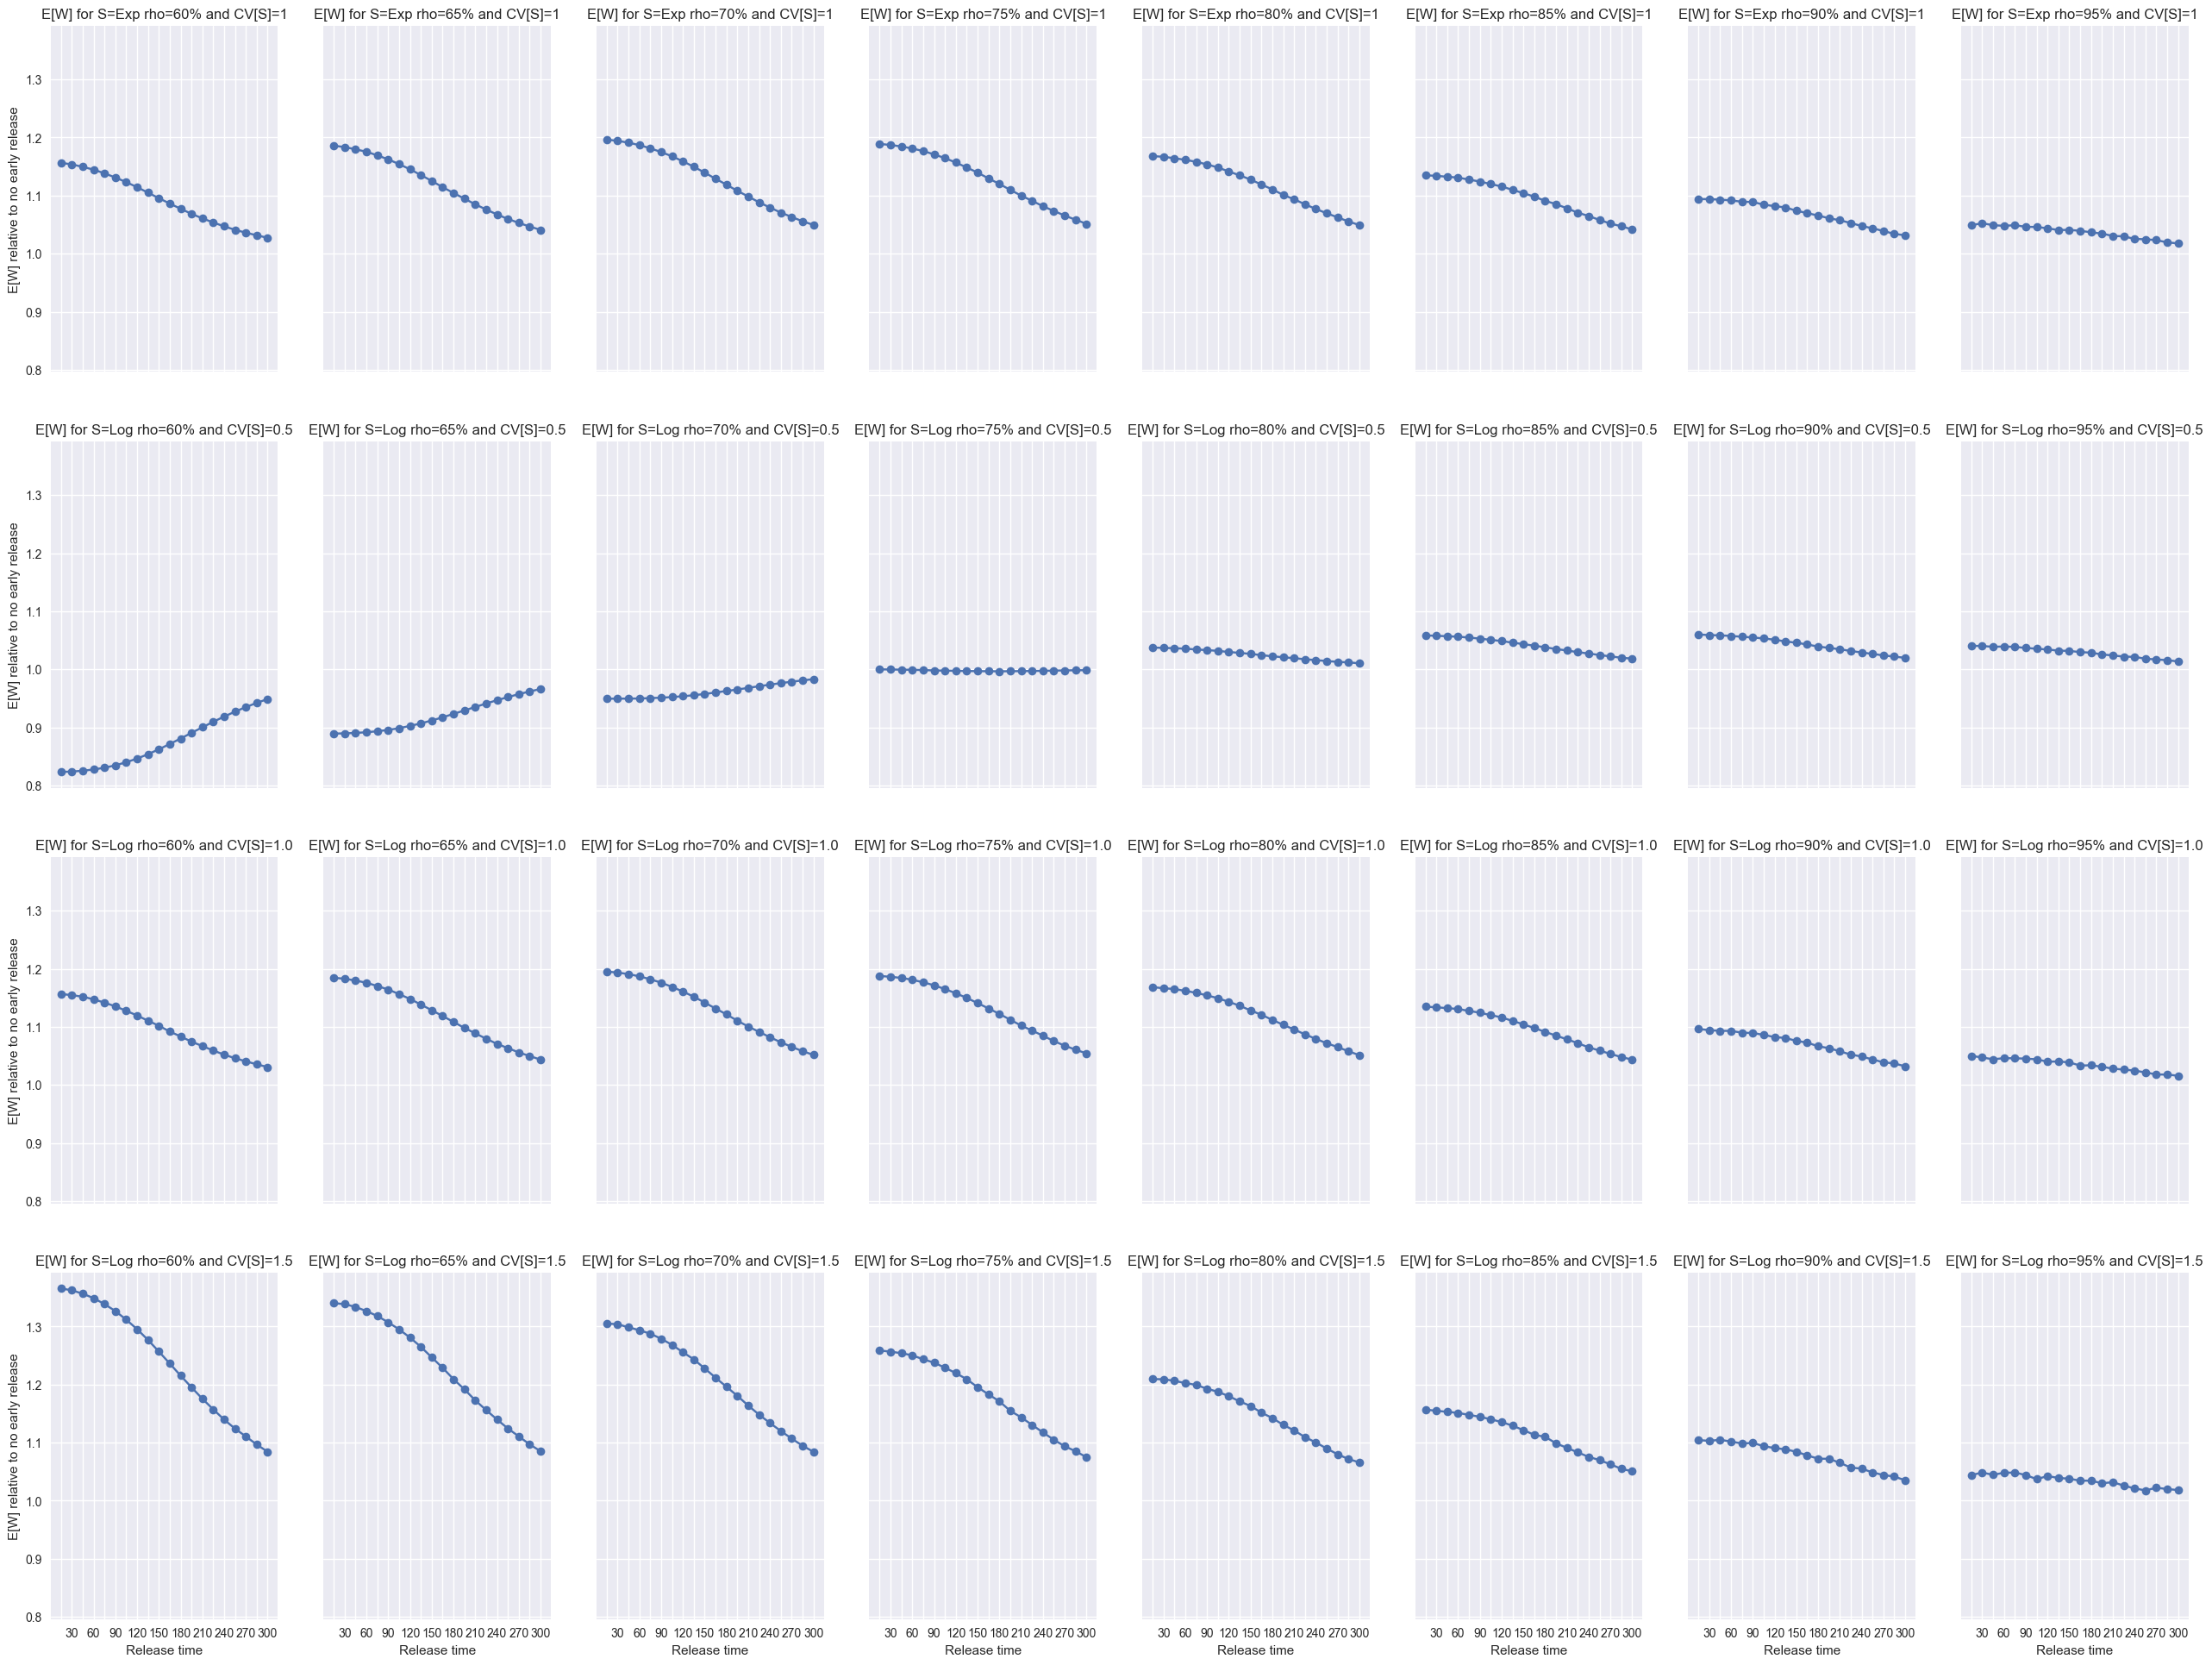

In [ ]:
fig, ax = plt.subplots(4, 8, figsize=(32, 24), sharex=True, sharey=True)

for i in range(4):
    if i == 0:
        S = "Exp"
        CVS = 1
    else:
        S = "Log"
        CVS = 0.5 * i
    for j in range(8):
        rho = 0.60 + j * 0.05
        plot_sim_data = []
        for rec in [r for r in data if r["S"] == S and r["model_CV[S]"] == CVS and r["model_rho"] == rho]:
            time = rec["time"]
            name = rec["name_short"]
            plot_sim_data.append({"time": time, "name": name, "E[W]": rec["E[W]rel"]})

        plot_sim_data = sorted(plot_sim_data, key=lambda rec: rec["time"])

        x = [rec["time"] for rec in plot_sim_data]
        y_sim = [rec["E[W]"] for rec in plot_sim_data]

        ax1 = ax[i][j]

        ax1.plot(x, y_sim, marker='o')
        ax1.set_xticks(x)
        for label in ax1.xaxis.get_ticklabels()[::2]:
            label.set_visible(False)
        if j == 0:

            ax1.set_ylabel("E[W] relative to no early release")
        if i == 3:
            ax1.set_xlabel("Release time")

        ax1.set_title(f"E[W] for S={S} rho={rho * 100:0.0f}% and CV[S]={CVS}")

# fig.savefig("images/Model06-EWrel-details.png", format="png", bbox_inches='tight', pad_inches=0)

### Plot CV[W]

Maximum relative delta (W): 21.47%
Maximum relative delta (V): 9.74%


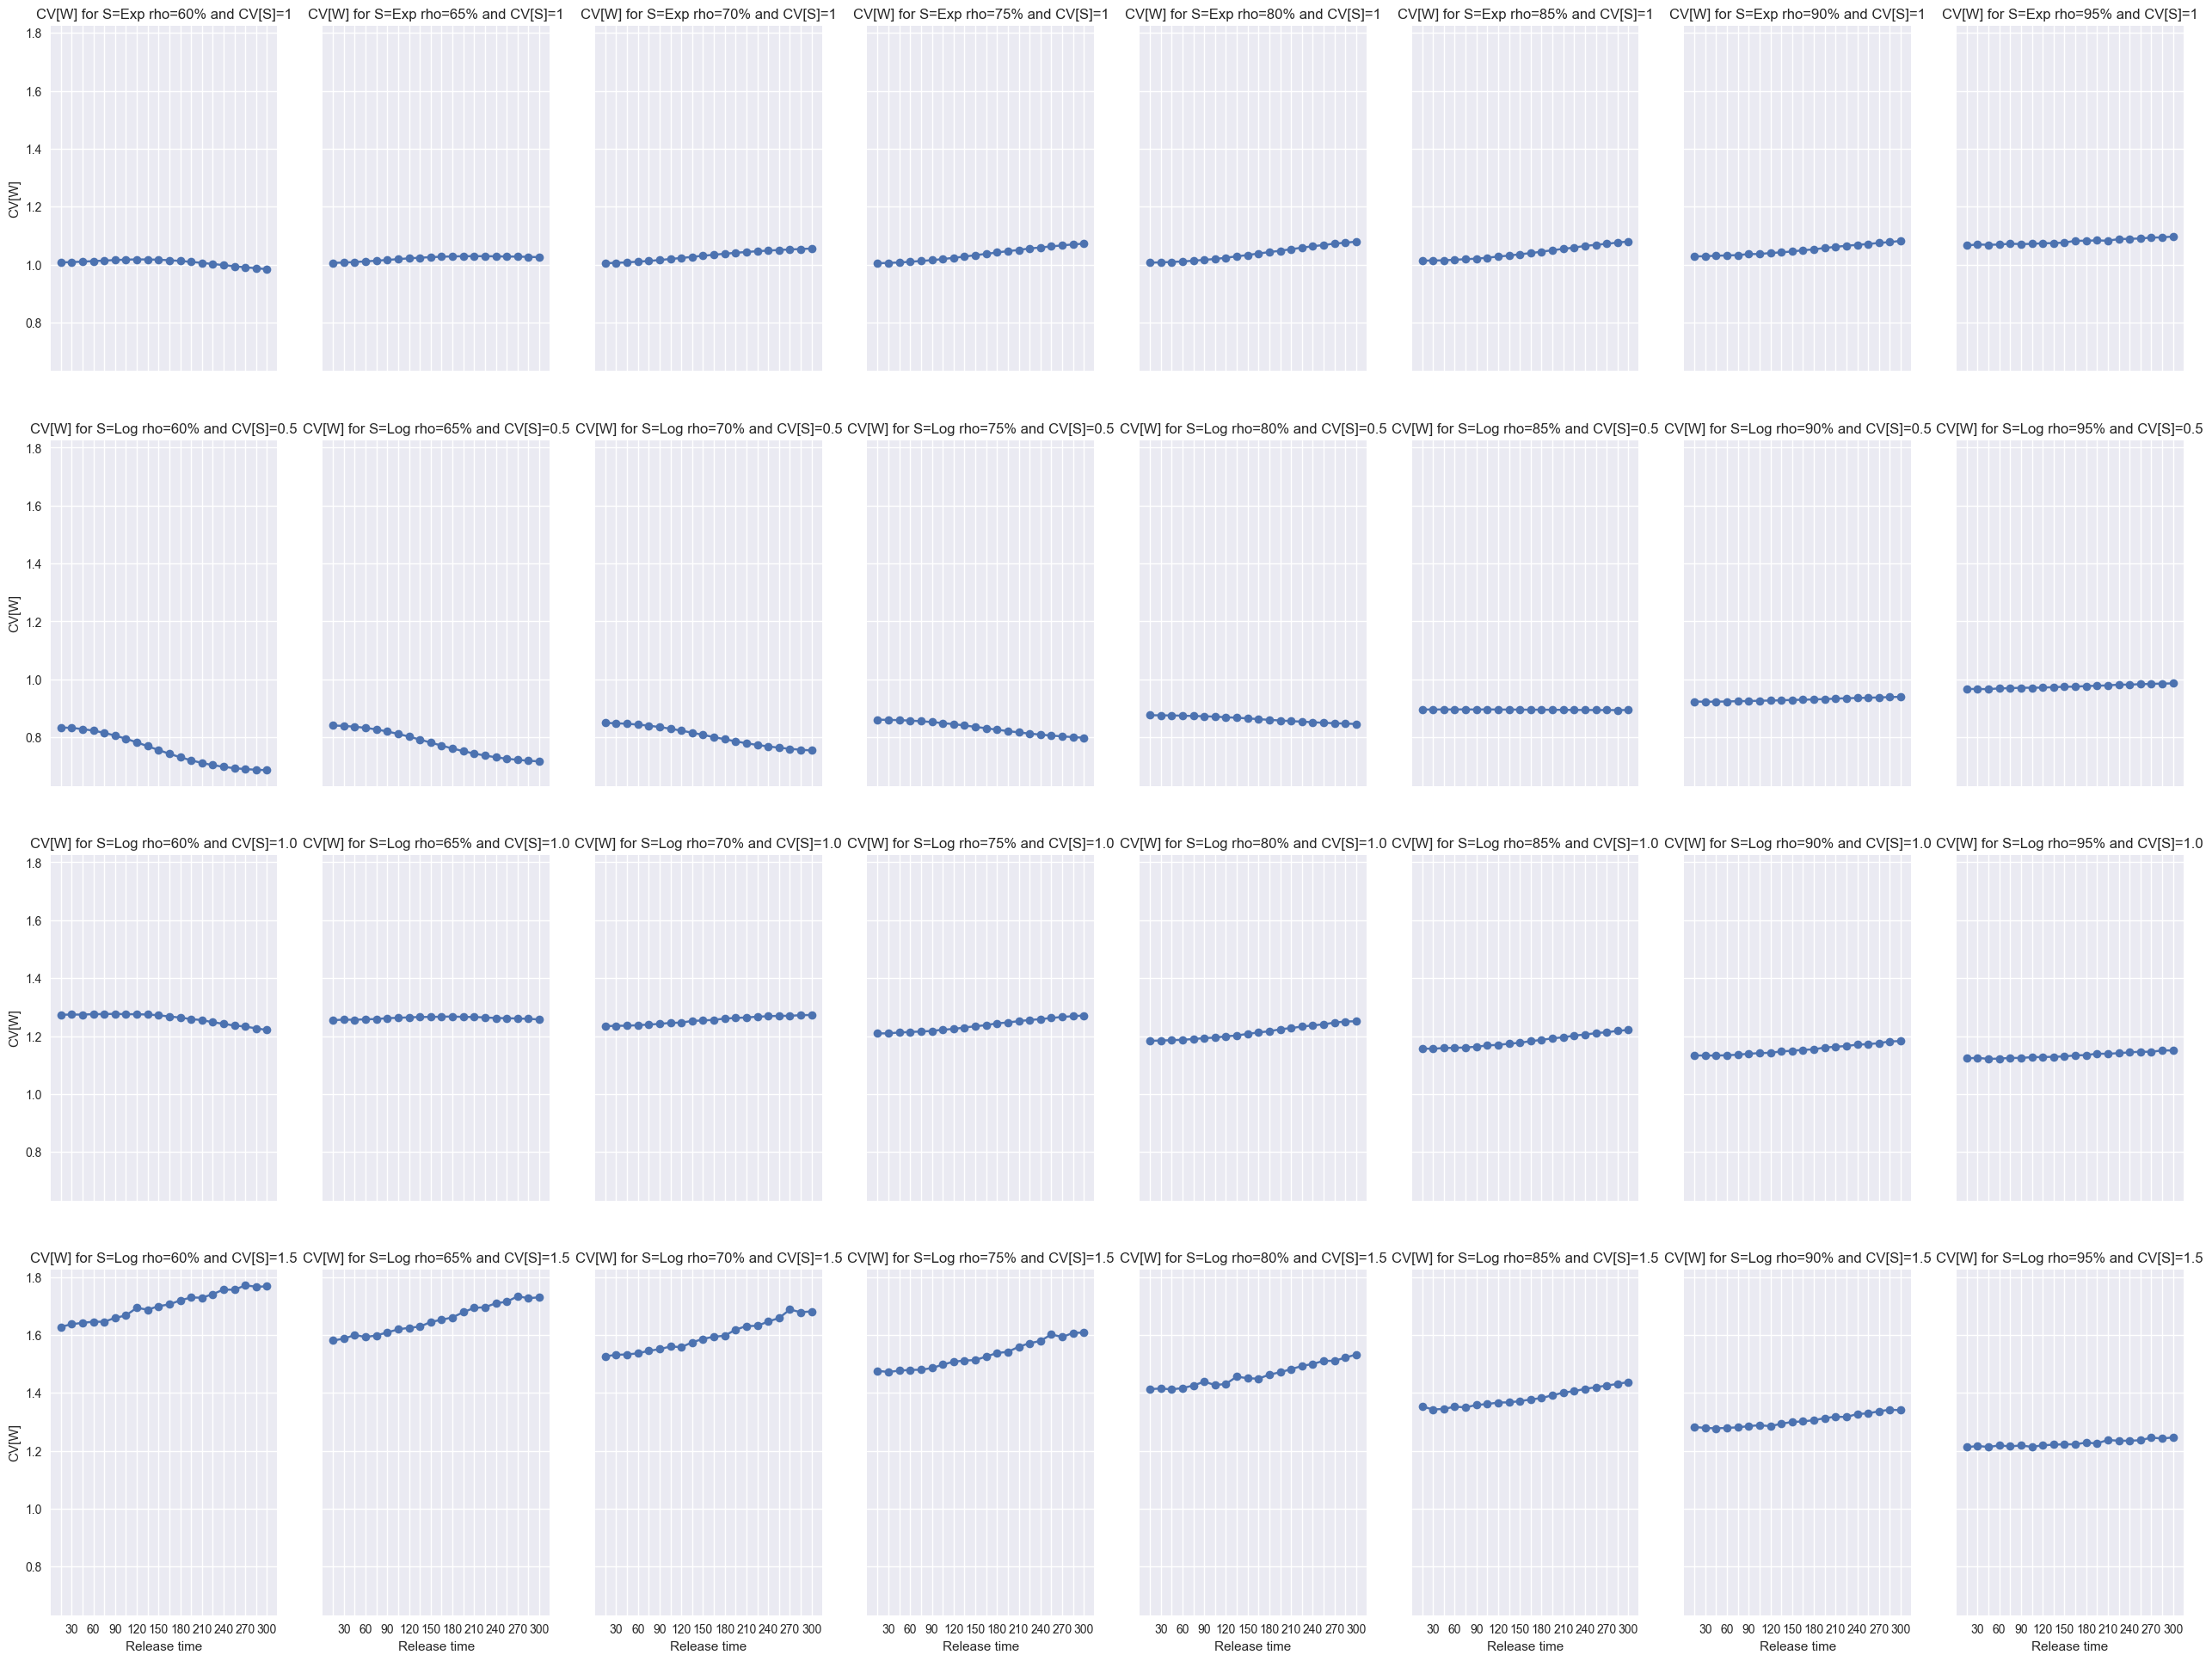

In [ ]:
fig, ax = plt.subplots(4, 8, figsize=(32, 24), sharex=True, sharey=True)

max_rel_delta_W = 0
max_rel_delta_V = 0

for i in range(4):
    if i == 0:
        S = "Exp"
        CVS = 1
    else:
        S = "Log"
        CVS = 0.5 * i
    for j in range(8):
        rho = 0.60 + j * 0.05
        plot_sim_data = []
        for rec in [r for r in data if r["S"] == S and r["model_CV[S]"] == CVS and r["model_rho"] == rho]:
            time = rec["time"]
            name = rec["name_short"]
            plot_sim_data.append({"time": time, "name": name, "CV[W]": rec["CV[W]"], "CV[V]": rec["CV[V]"]})

        plot_sim_data = sorted(plot_sim_data, key=lambda rec: rec["time"])

        x = [rec["time"] for rec in plot_sim_data]
        y_sim = [rec["CV[W]"] for rec in plot_sim_data]
        y_sim_CVV = [rec["CV[V]"] for rec in plot_sim_data]

        rel_delta_W = abs((y_sim[-1]-y_sim[0])/y_sim[-1])
        max_rel_delta_W = max(max_rel_delta_W, rel_delta_W)
        rel_delta_V = abs((y_sim_CVV[-1]-y_sim_CVV[0])/y_sim_CVV[-1])
        max_rel_delta_V = max(max_rel_delta_V, rel_delta_V)

        ax1 = ax[i][j]

        ax1.plot(x, y_sim, marker='o')
        ax1.set_xticks(x)
        for label in ax1.xaxis.get_ticklabels()[::2]:
            label.set_visible(False)
        if j == 0:

            ax1.set_ylabel("CV[W]")
        if i == 3:
            ax1.set_xlabel("Release time")

        ax1.set_title(f"CV[W] for S={S} rho={rho * 100:0.0f}% and CV[S]={CVS}")

print(f"Maximum relative delta (W): {max_rel_delta_W * 100:.2f}%")
print(f"Maximum relative delta (V): {max_rel_delta_V * 100:.2f}%")

# fig.savefig("images/Model06-CVW-details.png", format="png", bbox_inches='tight', pad_inches=0)

### Plot $\rho$

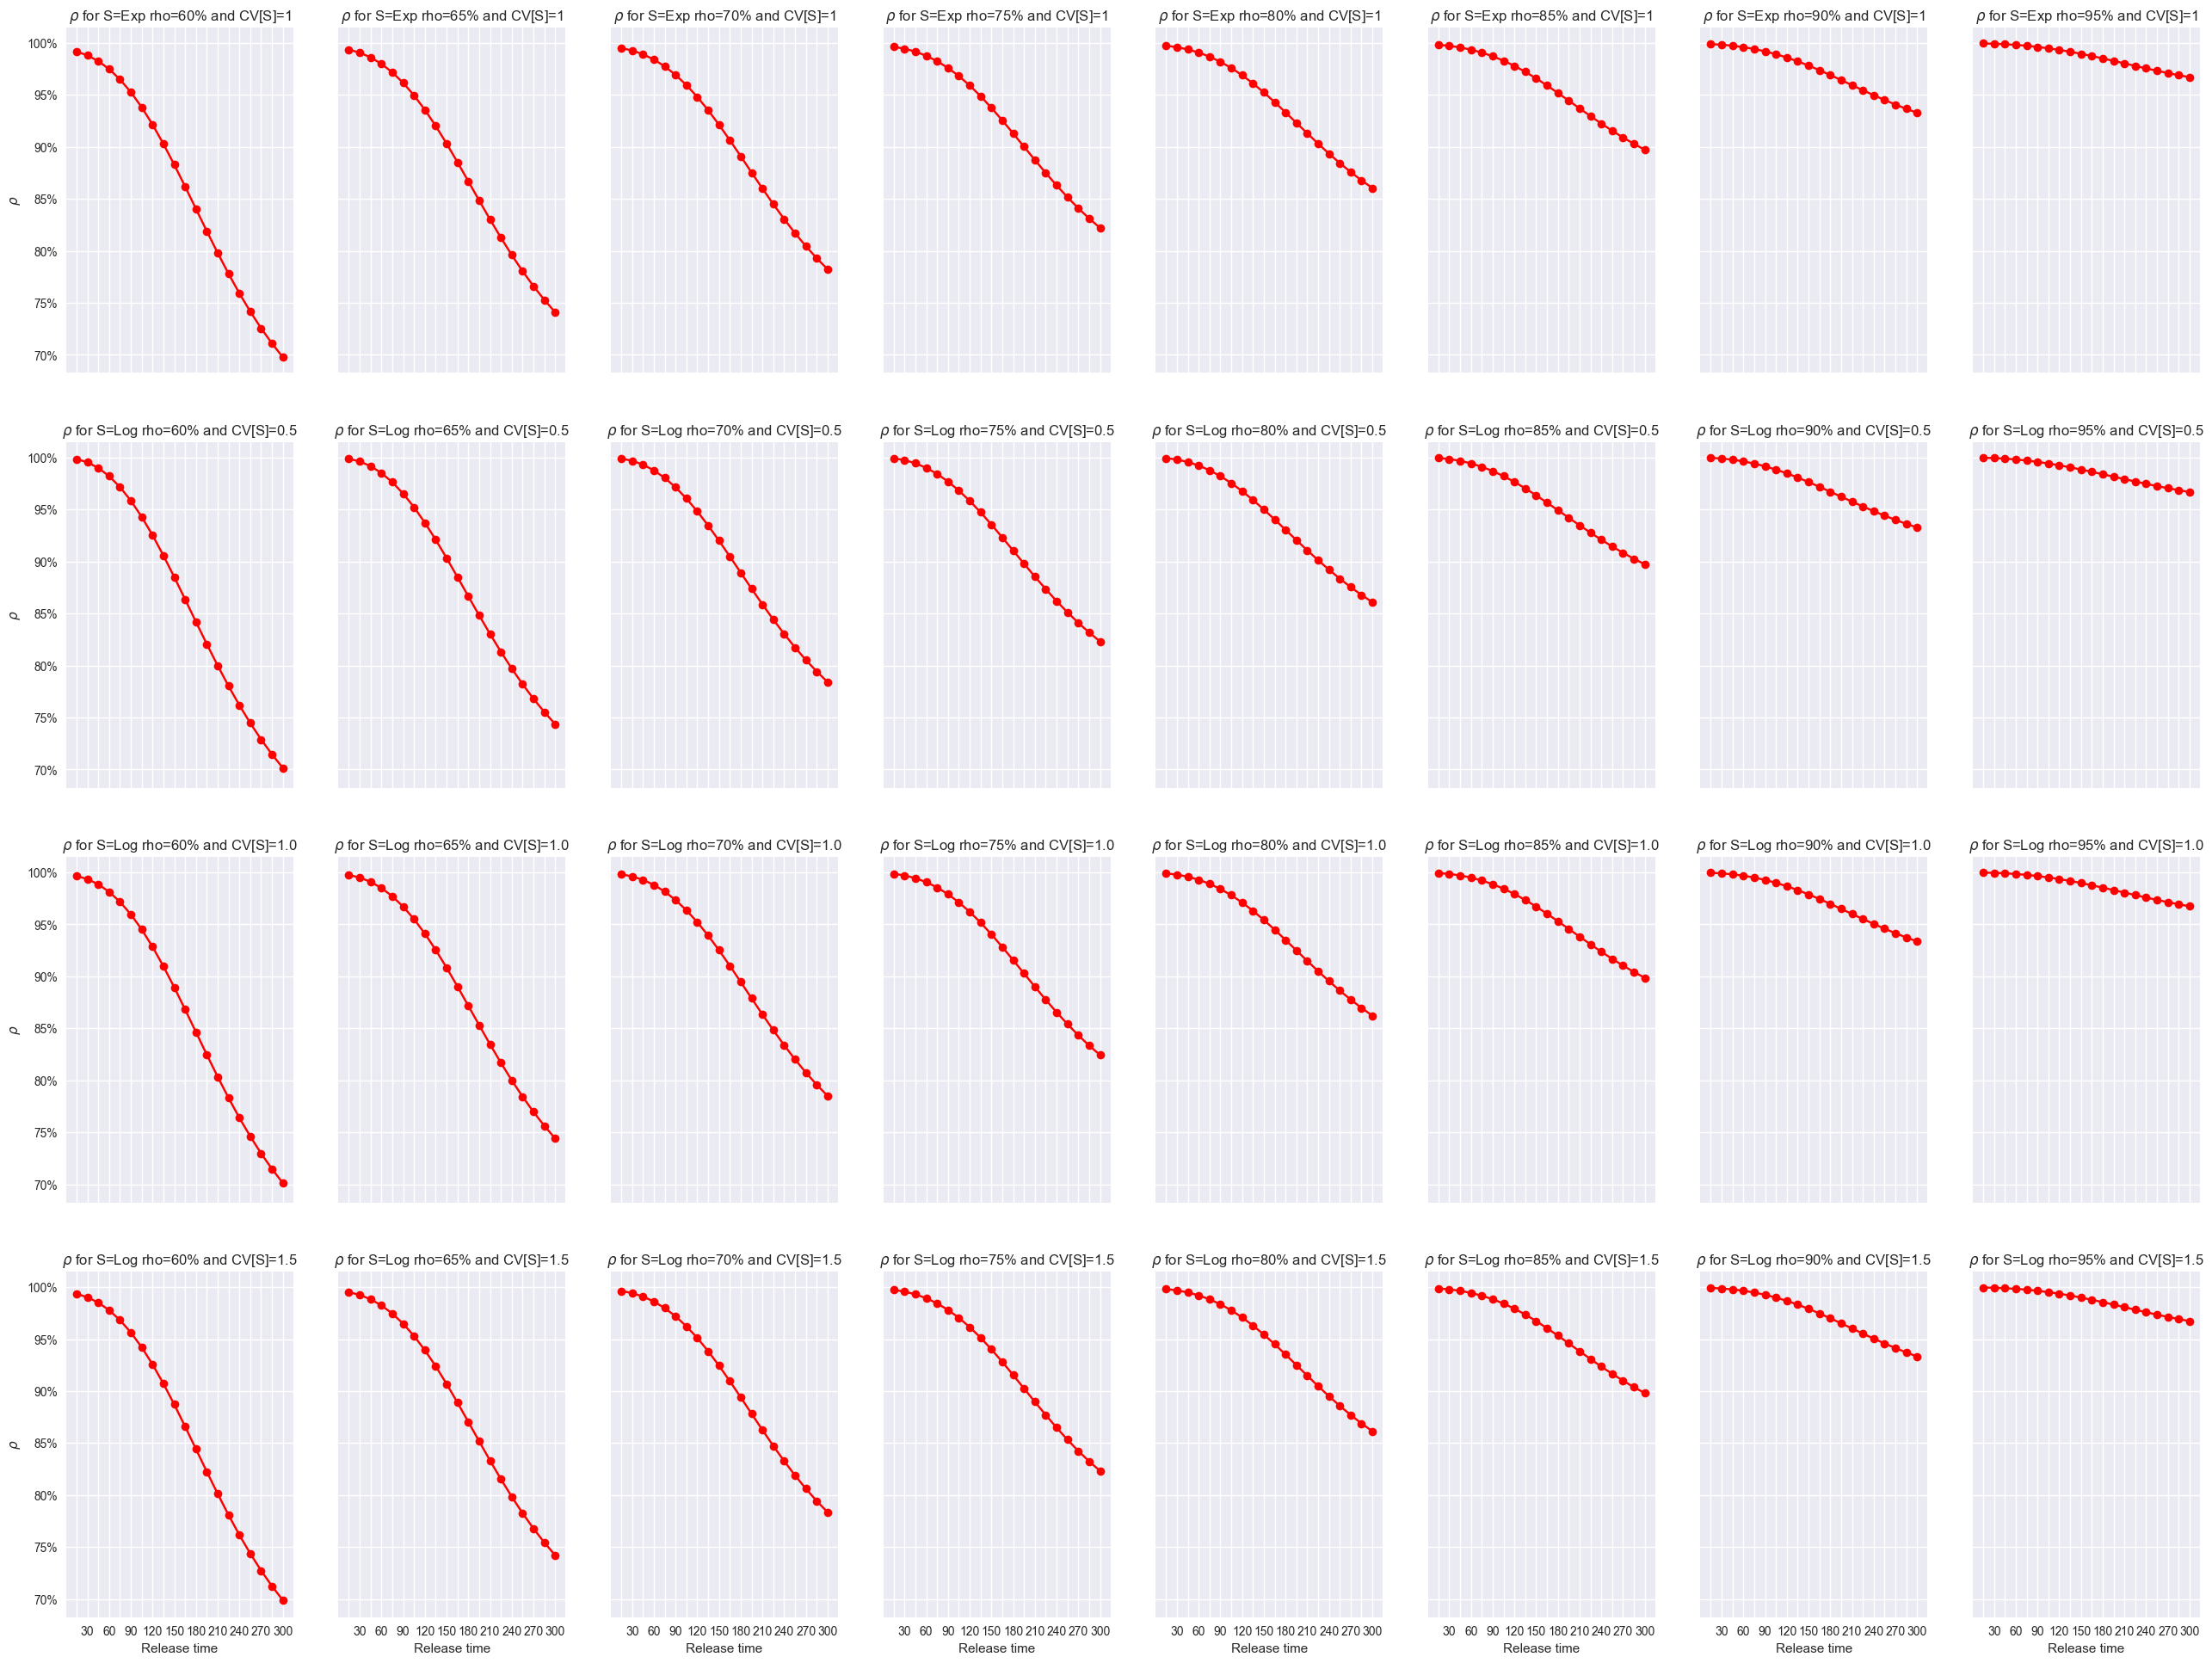

In [ ]:
fig, ax = plt.subplots(4, 8, figsize=(32, 24), sharex=True, sharey=True)

for i in range(4):
    if i == 0:
        S = "Exp"
        CVS = 1
    else:
        S = "Log"
        CVS = 0.5 * i
    for j in range(8):
        rho = 0.60 + j * 0.05
        plot_sim_data = []
        for rec in [r for r in data if r["S"] == S and r["model_CV[S]"] == CVS and r["model_rho"] == rho]:
            time = rec["time"]
            name = rec["name_short"]
            plot_sim_data.append({"time": time, "name": name, "rho": rec["rho"]})

        plot_sim_data = sorted(plot_sim_data, key=lambda rec: rec["time"])

        x = [rec["time"] for rec in plot_sim_data]
        y_sim = [rec["rho"] for rec in plot_sim_data]

        ax1 = ax[i][j]

        ax1.plot(x, y_sim, 'red', marker='o')
        ax1.set_xticks(x)
        for label in ax1.xaxis.get_ticklabels()[::2]:
            label.set_visible(False)
        ax1.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
        if j == 0:

            ax1.set_ylabel("$\\rho$")
        if i == 3:
            ax1.set_xlabel("Release time")

        ax1.set_title(f"$\\rho$ for S={S} rho={rho * 100:0.0f}% and CV[S]={CVS}")

# fig.savefig("images/Model06-rho-details.png", format="png", bbox_inches='tight', pad_inches=0)